In [4]:
# 데이터 분석 
import pandas as pd
import numpy as np

# 범주형 데이터 변환 
from sklearn.preprocessing import LabelEncoder # 이후부터 용어 변화 존재 
le = LabelEncoder()

# 머신러닝 지도학습, Regression 모델 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score

# 데이터 시각화 분석 라이브러리 
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 패치 표준

plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

In [31]:
iris = load_iris()


In [15]:
iris_df = pd.DataFrame(iris.data , columns = iris.feature_names)
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


### 3. Train / Test Split 

In [21]:
y = iris_df['petal width (cm)'] # small y 사용
X = iris_df.drop(['petal width (cm)'], axis = 1)# Capital X 사용 

In [22]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm)
0,5.1,3.5,1.4
1,4.9,3.0,1.4
2,4.7,3.2,1.3
3,4.6,3.1,1.5
4,5.0,3.6,1.4


8:2 는 모델이 좋게 보이게 하기 위함 ( 현격히 학습데이터가 부족할 경우만 )
7:3 은 이상적인 비율 학습/훈련

In [ ]:
from sklearn.model_selection import train_test_split

In [26]:
X_train , X_test  , y_train , y_test = train_test_split(X,y, test_size = 0.2 , random_state = 42 )
# random_state : 학습 시작 기준점 , 균일하게 학습시키기 위함 

In [ ]:
from sklearn.linear_model import LinearRegression

In [27]:
lr_model = LinearRegression()

In [29]:
lr_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
y_pred = lr_model.predict(X_test)

In [32]:
from sklearn.metrics import mean_squared_error , r2_score

In [35]:
mse = mean_squared_error(y_test , y_pred )
mse # 낮을수록 좋은 모델 

0.04633260332576443

In [36]:
r2 = r2_score(y_test , y_pred )
r2 # 높을수록 좋은 모델 

0.9271105193357898

<Axes: >

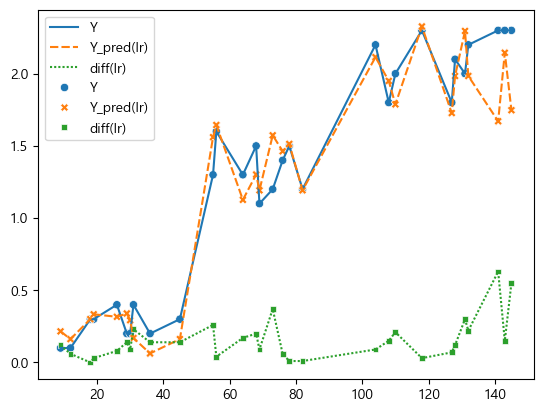

In [37]:
lr_df = pd.DataFrame(data = {'Y':y_test , 'Y_pred(lr)' : y_pred , 
                             'diff(lr)' : np.round(np.abs(y_test - y_pred),2)})
sns.lineplot(data = lr_df)
sns.scatterplot(data = lr_df)

- 모델의 예측성능은 높은 편이다.
- 140 구간에서 훈련 데이터와 예측 데이터의 갭이 가장 크다. 